In [1]:
import sys
import os
sys.path.append('..')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

import utilities.functions as functions
from utilities.functions import (
    retidos,
    calcula_viabilidade,
    analisar_retencao,
)

from utilities.descritiva import  (
    matriz_migracao,
    cria_base_decil_wide
)

In [2]:
import os
import os
os.getcwd()
import os
import pandas as pd
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 


In [3]:

publico_janeiro_dezembro = pd.read_parquet(BASE_PATH / "gold" / "publico_janeiro_dezembro.parquet")


In [4]:
dois_pedidos=publico_janeiro_dezembro[publico_janeiro_dezembro['num_pedidos_hist']==3]
dois_pedidos

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
8,0003d64cdba507ac0c770eae4c0b2b2d8fdf73c16a9751...,target,12,1,3,43.4,43.40,1,False,4
9,0003d64cdba507ac0c770eae4c0b2b2d8fdf73c16a9751...,target,1,2,3,60.9,30.45,2,False,5
16,0006f2ec8d33dc0ed8fe526cc3ec44d996e28b23df9e91...,control,12,1,3,42.0,42.00,1,False,4
17,0006f2ec8d33dc0ed8fe526cc3ec44d996e28b23df9e91...,control,1,2,3,72.5,36.25,2,False,6
30,00103d71d6cd1941893fa9048425aeec22a127a314836d...,target,12,1,3,197.0,197.00,1,False,9
...,...,...,...,...,...,...,...,...,...,...
137321,ffefbcdd233ac98a2dd62cd6cb6dda18512a62780d0ed4...,target,1,2,3,110.1,55.05,2,False,8
137322,fff1c81dc23006c8096d42b9cf8b720bbb5abf368ef2e8...,target,12,1,3,44.2,44.20,1,False,4
137323,fff1c81dc23006c8096d42b9cf8b720bbb5abf368ef2e8...,target,1,2,3,92.2,46.10,2,False,7
137336,fff65bb91bc76d4132ced502dffbc2d8b8c0e68906a5fb...,control,12,1,3,49.0,49.00,1,False,4


In [5]:
dois_pedidos=publico_janeiro_dezembro[publico_janeiro_dezembro['pedidos_sum']=='2']['customer_id'].unique()
amostra_aleatoria =publico_janeiro_dezembro[publico_janeiro_dezembro['customer_id'].isin(dois_pedidos)]
df_stats_mes = amostra_aleatoria.groupby(['order_created_month', 'pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique')
).round(2)
matriz_migracao(amostra_aleatoria,mes_0=12,mes_1=1,group_by_extra='pedidos_sum')

,mes_12,mes_1,is_target,pedidos_sum,total_clientes
0,0,1,control,10,22
1,0,1,control,10+,36
2,0,1,control,2,2814
3,0,1,control,3,1149
4,0,1,control,4,786
5,0,1,control,5,484
6,0,1,control,6,273
7,0,1,control,7,143
8,0,1,control,8,53
9,0,1,control,9,34


Calculando retencao considerando dois ou + pedidos

In [6]:
df_1,clientes_retidos_1=retidos(publico_janeiro_dezembro, mes0=12, mes1=1,pedidos=1)
print(clientes_retidos_1)

           retidos   base  taxa_retencao
is_target                               
control      17981  29978       0.599807
target       26646  38705       0.688438


In [7]:
retencao_pedido_1=analisar_retencao(df_1)
retencao_pedido_1

{'target_retencao': 0.688438,
 'control_retencao': 0.599807,
 'lift_absoluto': 0.088632,
 'lift_relativo_percent': 14.78,
 'target_success': 26646,
 'target_total': 38705,
 'control_success': 17981,
 'control_total': 29978,
 'z_stat': 24.14837,
 'p_value': 0.0,
 'significativo': True}

Calculando retencao considerando tres ou + pedidos

In [8]:
df_2,clientes_retidos_2=retidos(publico_janeiro_dezembro, mes0=12, mes1=1,pedidos=2)
print(clientes_retidos_2)

           retidos   base  taxa_retencao
is_target                               
control      12683  29978       0.423077
target       18710  38705       0.483400


In [10]:
publico_janeiro_dezembro.head()

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,12,1,2,88.8,88.80,1,False,7
1,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,1,1,2,88.8,88.80,1,False,7
2,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,12,1,2,47.6,47.60,1,False,4
3,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,1,1,2,47.6,47.60,1,False,4
4,00021cd56b6d6c980c3b48ca0fdf8c53cf3fea776d74ab...,target,12,2,5,31.9,15.95,2,False,2


In [9]:
retencao_pedido_2=analisar_retencao(df_2)
retencao_pedido_2

{'target_retencao': 0.4834,
 'control_retencao': 0.423077,
 'lift_absoluto': 0.060323,
 'lift_relativo_percent': 14.26,
 'target_success': 18710,
 'target_total': 38705,
 'control_success': 12683,
 'control_total': 29978,
 'z_stat': 15.739138,
 'p_value': 0.0,
 'significativo': True}

Viabilidade 

In [ ]:
resultados, agg = calcula_viabilidade(
    publico_janeiro_dezembro,
    mes_campanha=12,
    mes_seguinte=1,
    coupon_value=10.0,   
    margin_rate=0.12     
)

resultados


Calculando retencao separadamente para outliers

In [11]:
orderns_de=publico_janeiro_dezembro[publico_janeiro_dezembro['order_created_month']==12]

In [12]:
distance = 1.5 * (np.nanpercentile(orderns_de['total_amount_mes'], 75) - np.nanpercentile(orderns_de['total_amount_mes'], 25))
lim_sup=distance + np.nanpercentile(orderns_de['total_amount_mes'], 75)

<Axes: >

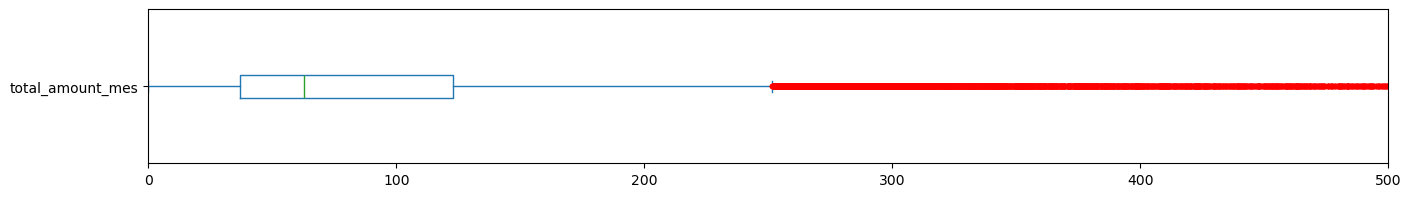

In [13]:
red_square = dict(markerfacecolor='r', markeredgecolor='r', marker='.')
orderns_de['total_amount_mes'].plot(kind='box', xlim=(0, 500), vert=False, flierprops=red_square, figsize=(16,2))

In [14]:
orderns_de['total_amount_mes'].describe().round(2)

count    68683.00
mean       105.74
std        135.34
min          0.00
25%         37.00
50%         62.80
75%        122.80
max       5044.94
Name: total_amount_mes, dtype: float64

In [15]:
pb_drop_dj = publico_janeiro_dezembro.drop(
    publico_janeiro_dezembro[
        (publico_janeiro_dezembro['total_amount_mes'] == 0) |
        (publico_janeiro_dezembro['total_amount_mes'] > lim_sup)
    ].index,
    axis=0
)

In [16]:
pb_drop_dj

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,12,1,2,88.8,88.80,1,False,7
1,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,1,1,2,88.8,88.80,1,False,7
2,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,12,1,2,47.6,47.60,1,False,4
3,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,1,1,2,47.6,47.60,1,False,4
4,00021cd56b6d6c980c3b48ca0fdf8c53cf3fea776d74ab...,target,12,2,5,31.9,15.95,2,False,2
...,...,...,...,...,...,...,...,...,...,...
137361,fffebe8f36625fbc708361eeaa301fee40b849e2bf4666...,target,1,2,4,96.3,48.15,2,False,7
137362,fffef917711775d1ba63ec1d8054f9705177edef950699...,control,12,1,2,23.8,23.80,1,False,1
137363,fffef917711775d1ba63ec1d8054f9705177edef950699...,control,1,1,2,23.8,23.80,1,False,1
137364,ffff43a3295b205e9024717bd803b218f49aa87c8e2b90...,control,12,1,2,59.0,59.00,1,False,5


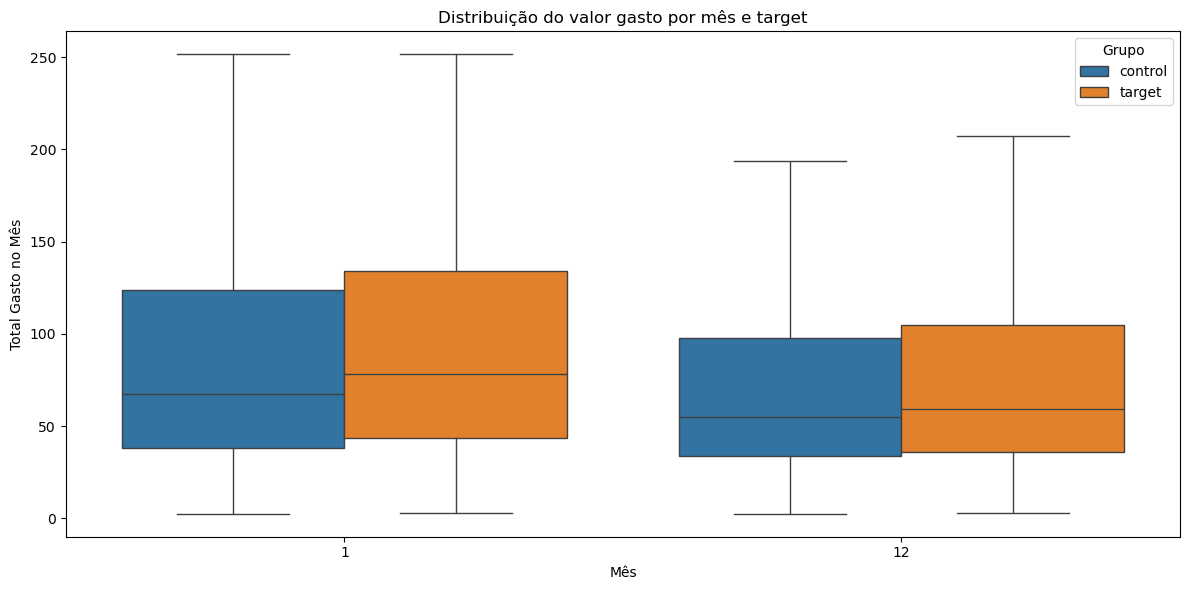

In [17]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=pb_drop_dj,
    x='order_created_month',               
    y='total_amount_mes',   
    hue='is_target',           
    showfliers=False          
)

plt.title('Distribuição do valor gasto por mês e target')
plt.xlabel('Mês')
plt.ylabel('Total Gasto no Mês')
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

In [18]:
pb_drop_dj_1,clientes_retidos_1=retidos(pb_drop_dj, mes0=12, mes1=1,pedidos=1)
print(clientes_retidos_1)

           retidos   base  taxa_retencao
is_target                               
control      12407  27644       0.448813
target       18470  35329       0.522800


In [19]:
pb_drop_dj_s=analisar_retencao(pb_drop_dj_1)
pb_drop_dj_s

{'target_retencao': 0.5228,
 'control_retencao': 0.448813,
 'lift_absoluto': 0.073986,
 'lift_relativo_percent': 16.48,
 'target_success': 18470,
 'target_total': 35329,
 'control_success': 12407,
 'control_total': 27644,
 'z_stat': 18.43116,
 'p_value': 0.0,
 'significativo': True}

In [20]:
resultados_out, agg_out = calcula_viabilidade(
    pb_drop_dj,
    mes_campanha=12,
    mes_seguinte=1,
    coupon_value=10.0,   
    margin_rate=0.12     
)

resultados_out


{'pedidos_por_cliente_dec_control': 1.7375922442482998,
 'pedidos_por_cliente_dec_target': 1.8374989385490674,
 'pedidos_por_cliente_jan_control': 2.169552018378733,
 'pedidos_por_cliente_jan_target': 2.3771110018035744,
 'inc_pedidos_dec': 3529.603602951818,
 'inc_pedidos_jan': 6329.511199540534,
 'inc_pedidos_total': 9859.114802492353,
 'inc_gmv_dec': 136280.27872124143,
 'inc_gmv_jan': 226894.443515343,
 'inc_gmv_total': 363174.7222365844,
 'margem_incremental': 43580.96666839013,
 'base_target_dec': 35329,
 'custo_campanha': 353290.0,
 'lucro_incremental': -309709.03333160985,
 'roi': -0.8766425127561206,
 'coupon_value': 10.0,
 'margin_rate': 0.12}